
# Project Milestone One: Forming Your Team, Understanding the Problem, and Exploring the Data

#### **Due:** Midnight on March 29th (with 2-hour grace period) — **worth 25 points**

> **Note:** Because we must begin manual grading immediately, there will be *no* late period for this milestone.

This milestone is the first phase of your project. You’ll begin working in teams, select your dataset, perform basic exploratory data analysis (EDA), and frame your classification problem.  

1. **Form your project team.**  
   Convene your team and complete the **Team Contract** (available in your Homework Repository). This is **due on Sunday, March 22nd** at midnight (along with Homework 07). Each member must review and sign it before submission.

2. **Select a team leader.**  
   Choose one team member to act as the **Gradescope submitter** for your team. The entire team should collaborate on the notebook, but only the leader will submit.

3. **Explore your dataset and frame your task.**  
   You’ll work through the notebook to  
   - Examine both provided datasets,  
   - Choose one for your project,
   - Be able to describe the classification problem you’ll be solving in business or applied terms,
   - Conduct basic EDA to understand its structure and challenges, and
   - Spot potential challenges, propose solutions, and select appropriate performance metrics.  

This milestone focuses on understanding your data and clearly articulating what your model will eventually predict. You are not required to build a model yet (that will happen in Milestone 2) but of course you have lots of example models to choose from previous Homeworks and Coding Notebooks and you may wish to explore a baseline model as you do this first phase of your project.


### The Datasets

The final project is a **classification task** using **one of two datasets**—one image-based and one text-based. These are the two
domains we have studied in detail, after learning the fundamentals in the first three weeks, and you have all you need to approach either of these datasets with confidence.

#### **1. Food-101 (Images)**  
A web-scraped collection of approximately **101,000 color photos** across **101 food categories** (≈ 800 train / 100 validation / 100 test per class).  
Images vary widely in **lighting, composition, and color balance**, making this dataset excellent for practicing **data cleaning**, **EDA**, and **augmentation** techniques such as random crops, flips, and color jitter.

#### **2. HuffPost News Category (Text)**  
Roughly **200,000 short news items** labeled into **41 topical categories** (e.g., *POLITICS*, *ENTERTAINMENT*, *PARENTING*).  
Each record contains a **headline**, a **short description**, which we will concatenate with a separator token to make a single text string:
> `"headline [SEP] short_description"`.
>
The `[SEP]` token simply marks where the headline ends and the description begins—mirroring conventions used in transformer models such as BERT.


### What To Do


We’ve provided template code to start your project:

* **Download** your selected dataset.
* **Visualize** a few representative samples (images or text excerpts).

After reviewing both datasets, you’ll **choose one** for your semester project.

In the sections that follow:

* **Problem One — Exploratory Data Analysis (EDA):**
  Quantify scale and structure, check class balance, and note any missing/duplicate or inconsistent entries.

* **Problem Two — Challenges & Solution Paths:**
  Identify likely issues (e.g., overlapping categories, imbalanced labels, data-quality problems, length/size variance) and outline practical remedies you would try. *(No model training required.)*

For tips on working with **Hugging Face Datasets** (helpful for large datasets), see the **Appendix**.

> **Important:** Keep only the section for the dataset you select and delete the other before submitting **Milestone 1**.


In [1]:
# ============================================
# Useful Imports
# ============================================

# --- Standard Libraries
import os
import time
import math
import random
from collections import Counter

# --- Core Data / Numerics
import numpy as np
import pandas as pd

# --- Visualization
import matplotlib.pyplot as plt
# import seaborn as sns              # optional
import matplotlib.ticker as mticker  # optional (for formatted axes)

# --- NLP / Tokenization
import spacy                         # used for text preprocessing (HuffPost)

# --- Progress Tracking
from tqdm import tqdm                # optional (nice for loops)

from IPython.display import display

# --- TensorFlow / Keras (Deep Learning)
import tensorflow as tf
from tensorflow.keras import layers, models, Input, callbacks, regularizers, initializers
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, MaxPooling2D, Conv2D,
    SeparableConv2D, GlobalAveragePooling2D, GlobalMaxPooling2D, BatchNormalization
)

# --- (Optional) Classical ML Baseline Tools
# from sklearn.pipeline import Pipeline
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score


# ============================================
# Global Configuration & Small Utilities
# ============================================

# Reproducibility
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)   # sets Python, NumPy, and TensorFlow seeds

# Utility: format seconds as HH:MM:SS

"""
Example usage to time your code:

start_time = time.time()
# ... your code here ...
print("Execution Time:", format_hms(time.time() - start_time))
"""

def format_hms(seconds: float) -> str:
    """Convert seconds to HH:MM:SS format."""
    return time.strftime("%H:%M:%S", time.gmtime(seconds))


In [2]:
# Install into the kernel's own Python (works inside venvs and Colab)
import sys
!{sys.executable} -m pip install -U datasets pillow

/Users/serge/projects/BU/Module-7-Milestones/.venv/bin/python: No module named pip


In [3]:
# --- Hugging Face Datasets

from datasets import load_dataset, DatasetDict
from datasets.features import ClassLabel

## Prelude: Choose your dataset and take a first look

You’ll pick **one** dataset—either **Food-101 (images)** or **HuffPost (text)**—and run the starter cells to confirm it loads, view class stats, and skim a few samples.

* **Food-101 (images):** 101 classes of web photos with **inconsistent lighting, white balance, color casts, and composition** (plus varying resolutions). These natural quirks make augmentation and input-pipeline choices meaningful.
* **HuffPost (text):** ~200k headline/summary pairs across 41 topics with **class imbalance** and some **category overlap**—good for trying stratified splits and reporting macro-F1 in addition to accuracy.

After you review the two sections below (download → minimal EDA → split), **keep one and delete the other.** Stick with your choice for the entire project.

> **Note:** We use Hugging Face **Dataset/DatasetDict** objects (table-like datasets), not NumPy/Pandas arrays. Most of what you need to know is contained in the template code, but see the **Appendix** for more information on HG Datasets.


---

### Dataset Two (Text): HuffPost Dataset

#### **Load HuffPost (headline + summary + category)**

**Note:** This loads a **Hugging Face `Dataset`**, not a NumPy array or Pandas DataFrame.
- Each record is a **dictionary** with fields such as `"headline"`, `"short_description"`, and `"category"`.
- You can access columns by name (e.g., `huff["headline"]`) and check dataset size with `len(huff)`.
- Treat it as a table of text fields — you’ll handle tokenization and vectorization later during preprocessing.
- The typical BERT-compatible separator is used to construct the sample texts

        `headline [SEP] short-description`



In [4]:
# JSON mirror that preserves fields: headline, short_description, category, authors, link, date
URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff_all = load_dataset("json", data_files=URL, split="train")

print(huff_all)
print("Columns:", huff_all.column_names)
print("Total rows:", len(huff_all))

Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total rows: 200853


#### **Quick sanity checks (peek at a row)**

In [5]:
ex = huff_all[0]
print("One example:")
print("  category          :", ex.get("category"))
print("  headline          :", (ex.get("headline") or "")[:120])
print("  authors           :", (ex.get("authors") or "")[:120])
print("  short_description :", (ex.get("short_description") or "")[:120])
print("  date              :", ex.get("date"))

One example:
  category          : CRIME
  headline          : There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV
  authors           : Melissa Jeltsen
  short_description : She left her husband. He killed their children. Just another day in America.
  date              : 2018-05-26 00:00:00


#### **Print 10 random samples (combined text with separator, no truncation)**

In [6]:
# Show k random lines: "headline [SEP] short_description"

k = 10
seed = 7
rng = random.Random(seed)
idxs = rng.sample(range(len(huff_all)), k)

for i in idxs:
    ex = huff_all[i]
    print("  category          :", ex.get("category"))
    print("  headline          :", (ex.get("headline") or ""))
    print("  short_description :", (ex.get("short_description") or ""))
    print("  sample text       :", (ex.get("headline") or "")+'  [SEP]  '+ (ex.get("short_description") or ""))
    print()

  category          : ENTERTAINMENT
  headline          : Pregnant Kim Kardashian Rocks A Sheer Jumpsuit At The Airport
  short_description : Forget what you thought you knew about maternity style, because Kim's changing the game.
  sample text       : Pregnant Kim Kardashian Rocks A Sheer Jumpsuit At The Airport  [SEP]  Forget what you thought you knew about maternity style, because Kim's changing the game.

  category          : WOMEN
  headline          : How I Outran Misogyny
  short_description : "I have started running to retrain the way my brain sees my body, not as a sexual object but as a tool to get things done."
  sample text       : How I Outran Misogyny  [SEP]  "I have started running to retrain the way my brain sees my body, not as a sexual object but as a tool to get things done."

  category          : RELIGION
  headline          : A Prayer From the Mall of America
  short_description : I thank you for the Bloomington Police Department, and the Mall of America Security

#### **(Optional) Save splits to disk (reload later without re-splitting)**

We provide this in case you want to save the dataset to your local disk. Saving Food-101 splits to disk is not recommended unless you have ample local storage (it's huge!).

In [7]:
# huff.save_to_disk("huffpost_splits")        # save
# from datasets import load_from_disk
# huff = load_from_disk("huffpost_splits")  # reload when needed

---

## Problem 1 – Choose the Dataset (10 pts)

#### Objective
In this problem, you will explore the two provided datasets and select one to use for your final project.  
Your goal is to understand the structure, content, and challenges of the dataset through basic exploratory data analysis (EDA).  
By the end of this Milestone notebook, you should be able to explain what makes the dataset interesting, identify potential modeling challenges (e.g., imbalance, ambiguity, quality issues), and justify why it is a good choice for your classification project.


#### What to Do
1. **Load both datasets** and examine the outputs of the template code provided.  
   After this brief inspection, **choose one dataset for your project** and **delete the template code for the other.**  For your chosen dataset, continue with the remaining steps.

2. **Inspect** the dataset's basic properties:  
   - **Number of samples and classes:**  
     Determine how many total examples and distinct categories are present. Verify that the counts match expectations (e.g., 101 food classes or 41 news topics).  
   - **Example records or images:**  
     View several samples to understand the input format, diversity, and potential quality issues.  
     For images, note lighting or composition differences; for text, read a few headlines and summaries to see how expressive they are (done for you in template code).
   - **Distribution of labels (check for imbalance):**  
     Plot or tabulate label frequencies to see whether some classes dominate. Imbalanced datasets can bias model training and may require special handling.  
   - **Missing or inconsistent data:**  
     Look for empty fields, unreadable images, duplicate entries, or mislabeled samples. Handle or document any issues you find.  
   - **Overlapping or ambiguous class labels:**  
     Identify categories that may not be clearly distinct—e.g., “apple pie” vs. “cheesecake,” or “POLITICS” vs. “WORLD NEWS.”  
     Ambiguity in labels can increase confusion between classes and reduce model accuracy.

3. **Visualize key aspects:**  
   Extend the template code to complete the EDA for your chosen dataset:  
   - **Images:**  
     Create visual summaries to better understand the data (some are implemented in the template code).  
     - Verify that the dataset is balanced across classes.  
     - Display a small grid of random images to check variation in appearance, composition, and background (done in template code).  
     - Compare image sizes to determine whether resizing or normalization will be needed.  
     - Examine lighting and color balance—many web-scraped photos vary widely in brightness, saturation, and white balance.  
   - **Text:**  
     Visualize class balance and linguistic properties (some implemented in the template code).  
     - Plot the number of samples per label to confirm class balance or imbalance.  
     - Compute basic text statistics such as average word count or vocabulary size.  
     - Examine examples for duplicates, near-duplicates, or entries that might fit multiple categories.  
     - *(Optional)* Generate a word-frequency plot or word cloud to highlight distinctive terms for a few classes.

4. **Answer the graded questions below.**


In [8]:
# ============================================================
# Section 1: Dataset Overview
# ============================================================
# Confirm row count, columns, and enumerate all 41 category names.

print(f"Total rows:        {len(huff_all):,}")
print(f"Columns:           {huff_all.column_names}")

categories = sorted(set(huff_all['category']))
print(f"Unique categories: {len(categories)}\n")

for i, c in enumerate(categories, 1):
    print(f"  {i:2d}. {c}")

Total rows:        200,853
Columns:           ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Unique categories: 41

   1. ARTS
   2. ARTS & CULTURE
   3. BLACK VOICES
   4. BUSINESS
   5. COLLEGE
   6. COMEDY
   7. CRIME
   8. CULTURE & ARTS
   9. DIVORCE
  10. EDUCATION
  11. ENTERTAINMENT
  12. ENVIRONMENT
  13. FIFTY
  14. FOOD & DRINK
  15. GOOD NEWS
  16. GREEN
  17. HEALTHY LIVING
  18. HOME & LIVING
  19. IMPACT
  20. LATINO VOICES
  21. MEDIA
  22. MONEY
  23. PARENTING
  24. PARENTS
  25. POLITICS
  26. QUEER VOICES
  27. RELIGION
  28. SCIENCE
  29. SPORTS
  30. STYLE
  31. STYLE & BEAUTY
  32. TASTE
  33. TECH
  34. THE WORLDPOST
  35. TRAVEL
  36. WEDDINGS
  37. WEIRD NEWS
  38. WELLNESS
  39. WOMEN
  40. WORLD NEWS
  41. WORLDPOST


Largest class:  POLITICS (32,739)
Smallest class: EDUCATION (1,004)
Median count:   3,405
Imbalance ratio (max / min):    32.6x
Imbalance ratio (max / median): 9.6x


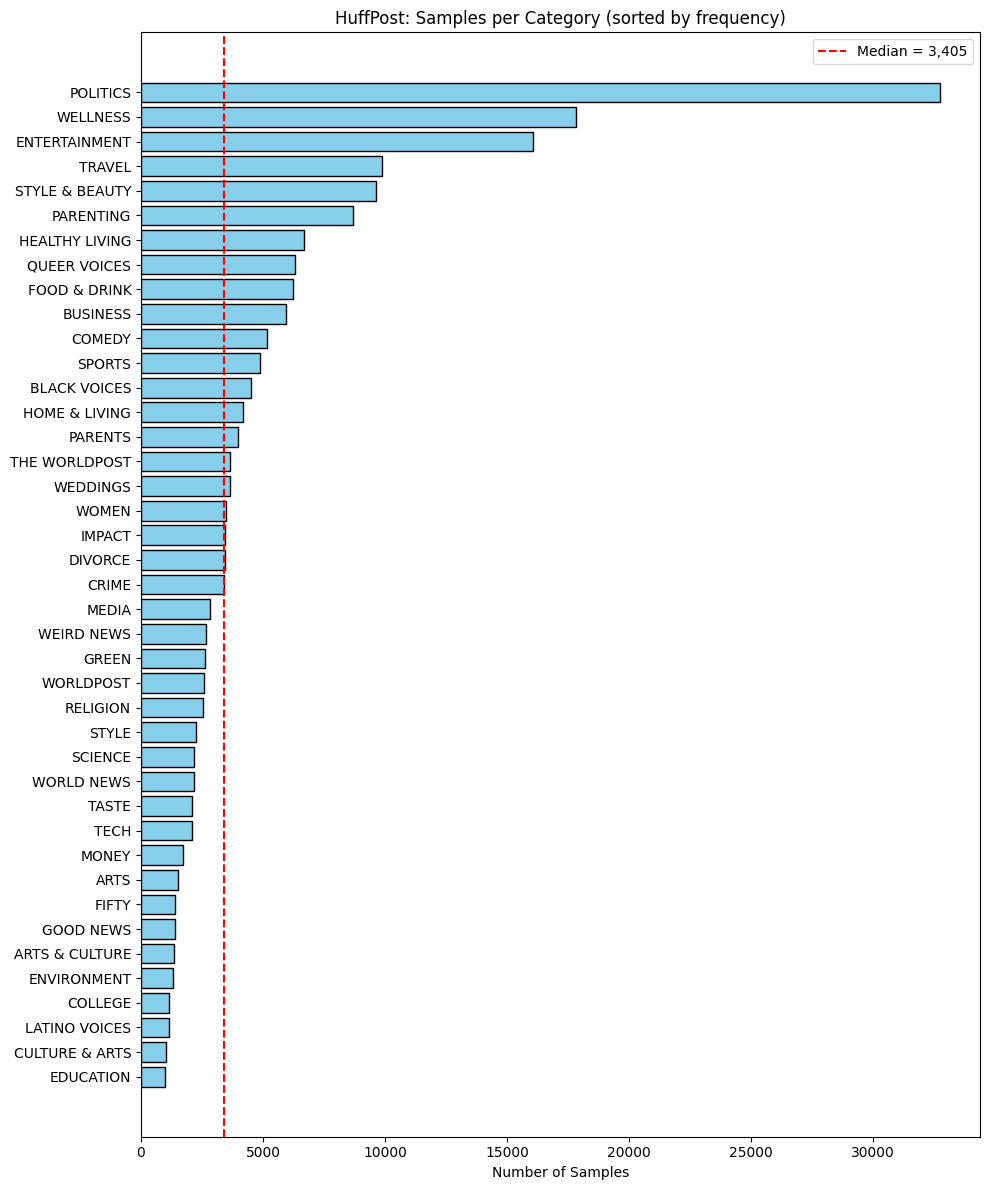

In [9]:
# ============================================================
# Section 2: Class Distribution
# ============================================================
# Count samples per category, compute imbalance ratio, and plot.
# Pattern reused from HW07 Counter(y) approach.

cat_counts = Counter(huff_all['category'])
cat_df = pd.DataFrame(cat_counts.most_common(), columns=['category', 'count'])

print(f"Largest class:  {cat_df.iloc[0]['category']} ({cat_df.iloc[0]['count']:,})")
print(f"Smallest class: {cat_df.iloc[-1]['category']} ({cat_df.iloc[-1]['count']:,})")
print(f"Median count:   {cat_df['count'].median():,.0f}")
print(f"Imbalance ratio (max / min):    {cat_df['count'].max() / cat_df['count'].min():.1f}x")
print(f"Imbalance ratio (max / median): {cat_df['count'].max() / cat_df['count'].median():.1f}x")

# Horizontal bar chart — sorted ascending so largest class is at the top visually
fig, ax = plt.subplots(figsize=(10, 12))
ax.barh(cat_df['category'][::-1], cat_df['count'][::-1], color='skyblue', edgecolor='black')
ax.set_xlabel('Number of Samples')
ax.set_title('HuffPost: Samples per Category (sorted by frequency)')
median_val = cat_df['count'].median()
ax.axvline(median_val, color='red', linestyle='--', label=f'Median = {median_val:,.0f}')
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# Section 3: Missing / Empty Data Audit
# ============================================================
# Check each text column for None and empty-string values.

text_cols = ['headline', 'short_description', 'authors']

for col in text_cols:
    vals = huff_all[col]
    n_none  = sum(1 for v in vals if v is None)
    n_empty = sum(1 for v in vals if v is not None and v.strip() == '')
    total_missing = n_none + n_empty
    print(f"{col:25s}: None={n_none:,}  Empty/whitespace={n_empty:,}  "
          f"Total missing={total_missing:,} ({total_missing/len(huff_all)*100:.2f}%)")

# Date column
dates = huff_all['date']
n_bad_date = sum(1 for v in dates if v is None or str(v).strip() == '')
print(f"{'date':25s}: None/Empty={n_bad_date:,}")

headline                 : None=0  Empty/whitespace=6  Total missing=6 (0.00%)
short_description        : None=0  Empty/whitespace=19,712  Total missing=19,712 (9.81%)
authors                  : None=0  Empty/whitespace=36,620  Total missing=36,620 (18.23%)
date                     : None/Empty=0


In [11]:
# ============================================================
# Section 4: Duplicate Analysis
# ============================================================
# Check for exact duplicate headlines, duplicate (headline+desc) pairs,
# and headlines that map to multiple categories (label ambiguity).

headlines    = huff_all['headline']
descriptions = huff_all['short_description']
cats         = huff_all['category']

# Exact headline duplicates
headline_counts = Counter(headlines)
dup_headlines = {h: c for h, c in headline_counts.items() if c > 1}
print(f"Unique headlines:              {len(headline_counts):,} / {len(huff_all):,}")
print(f"Duplicate headlines:           {len(dup_headlines):,} headlines appear 2+ times "
      f"({sum(dup_headlines.values()):,} total rows)")

# Exact (headline + description) duplicates
combined = [f"{h}|||{d}" for h, d in zip(headlines, descriptions)]
combined_counts = Counter(combined)
dup_combined = {k: c for k, c in combined_counts.items() if c > 1}
print(f"Exact (headline+desc) dupes:   {len(dup_combined):,} pairs "
      f"({sum(dup_combined.values()):,} total rows)")

# Headlines appearing in DIFFERENT categories — label ambiguity signal
from collections import defaultdict
headline_to_cats = defaultdict(set)
for h, cat in zip(headlines, cats):
    headline_to_cats[h].add(cat)
multi_cat = {h: c for h, c in headline_to_cats.items() if len(c) > 1}
print(f"\nHeadlines mapped to >1 category: {len(multi_cat):,}")
print("Examples:")
for h, cat_set in list(multi_cat.items())[:5]:
    print(f"  '{h[:80]}' -> {cat_set}")

Unique headlines:              199,344 / 200,853
Duplicate headlines:           717 headlines appear 2+ times (2,226 total rows)
Exact (headline+desc) dupes:   209 pairs (697 total rows)

Headlines mapped to >1 category: 102
Examples:
  'Gingerbread Dessert Recipes For The Best Holiday Baking' -> {'FOOD & DRINK', 'TASTE'}
  'Why We March' -> {'BLACK VOICES', 'GREEN'}
  'How Successful People Stay Calm' -> {'HEALTHY LIVING', 'BUSINESS'}
  'Hassan Rouhani's Economic Legacy May Be His Key To Winning A Second Term' -> {'THE WORLDPOST', 'WORLD NEWS'}
  'Coming Home' -> {'WOMEN', 'IMPACT'}


,Field,Mean,Median,Std,Min,Max,P90,P95
0,headline,9.5,10.0,3.1,0,44,13.0,15.0
1,short_description,19.7,19.0,14.4,0,243,41.0,47.0
2,combined,29.3,28.0,14.0,0,245,49.0,56.0


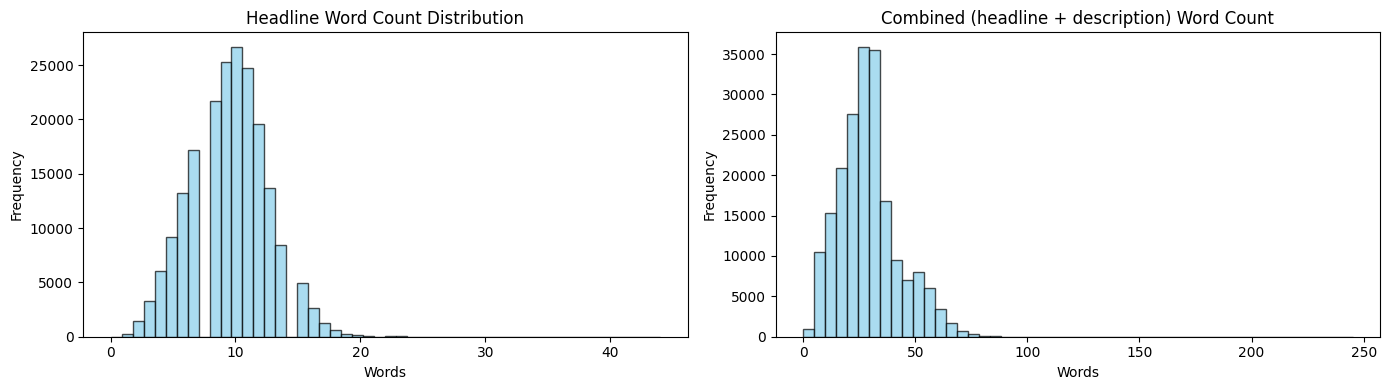

Total word tokens:  5,878,335
Vocabulary size:    239,960

Top 10 words:
  the            : 257,539
  to             : 163,141
  a              : 131,695
  of             : 127,668
  and            : 117,476
  in             : 94,387
  is             : 65,117
  for            : 63,369
  that           : 47,731
  on             : 46,246

Bottom 10 words (hapax legomena sample):
  think':        : 1
  allard         : 1
  hoorn's        : 1
  songline'      : 1
  sopa           : 1
  thorsten       : 1
  heins'         : 1
  lte            : 1
  azarenka,      : 1
  sumyk,         : 1


In [12]:
# ============================================================
# Section 5: Text Length Statistics
# ============================================================
# Word counts for headline, short_description, and combined text.
# Histogram pattern reused from HW07 (IMDb review lengths).
# Vocabulary stats pattern reused from Week06 Lesson Notebook.

def word_count(text):
    """Count whitespace-delimited words in a string."""
    return len(text.split()) if text and text.strip() else 0

headline_wc = [word_count(h) for h in huff_all['headline']]
desc_wc     = [word_count(d) for d in huff_all['short_description']]
combined_wc = [h + d for h, d in zip(headline_wc, desc_wc)]

# Summary statistics table
stats = pd.DataFrame({
    'Field': ['headline', 'short_description', 'combined'],
    'Mean':   [np.mean(headline_wc), np.mean(desc_wc), np.mean(combined_wc)],
    'Median': [np.median(headline_wc), np.median(desc_wc), np.median(combined_wc)],
    'Std':    [np.std(headline_wc), np.std(desc_wc), np.std(combined_wc)],
    'Min':    [np.min(headline_wc), np.min(desc_wc), np.min(combined_wc)],
    'Max':    [np.max(headline_wc), np.max(desc_wc), np.max(combined_wc)],
    'P90':    [np.percentile(headline_wc, 90), np.percentile(desc_wc, 90), np.percentile(combined_wc, 90)],
    'P95':    [np.percentile(headline_wc, 95), np.percentile(desc_wc, 95), np.percentile(combined_wc, 95)],
})
display(stats.round(1))

# Histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(headline_wc, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Headline Word Count Distribution')
axes[0].set_xlabel('Words'); axes[0].set_ylabel('Frequency')

axes[1].hist(combined_wc, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[1].set_title('Combined (headline + description) Word Count')
axes[1].set_xlabel('Words'); axes[1].set_ylabel('Frequency')
plt.tight_layout(); plt.show()

# Vocabulary size (simple whitespace split, lowercased)
all_words = []
for h, d in zip(huff_all['headline'], huff_all['short_description']):
    all_words.extend((h or '').lower().split())
    all_words.extend((d or '').lower().split())
print(f"Total word tokens:  {len(all_words):,}")
print(f"Vocabulary size:    {len(set(all_words)):,}")

# Top 10 and bottom 10 words (pattern from Week06 cell-11)
word_freq = Counter(all_words)
print("\nTop 10 words:")
for token, freq in word_freq.most_common(10):
    print(f"  {token:<15}: {freq:,}")
print("\nBottom 10 words (hapax legomena sample):")
for token, freq in word_freq.most_common()[-10:]:
    print(f"  {token:<15}: {freq:,}")

In [13]:
# ============================================================
# Section 6: Overlapping / Ambiguous Categories
# ============================================================
# Programmatically find category pairs that share significant words,
# indicating potential label confusion.

existing_cats = set(huff_all['category'])
cat_list = sorted(existing_cats)

# Find category pairs sharing non-trivial words
print("=== Categories sharing significant words ===\n")
ignore_words = {'the', 'and', '&', 'a', 'of'}
overlap_pairs = []
for i, a in enumerate(cat_list):
    for b in cat_list[i+1:]:
        a_words = set(a.lower().replace('&', ' ').split()) - ignore_words
        b_words = set(b.lower().replace('&', ' ').split()) - ignore_words
        shared = a_words & b_words
        if shared:
            count_a = cat_counts.get(a, 0)
            count_b = cat_counts.get(b, 0)
            overlap_pairs.append((a, b, shared, count_a, count_b))
            print(f"  {a} ({count_a:,}) <-> {b} ({count_b:,})  [shared: {shared}]")

# Highlight the most confusable groups
print("\n=== Key confusable groups (likely category merges) ===")
merge_groups = [
    ["ARTS", "ARTS & CULTURE", "CULTURE & ARTS"],
    ["THE WORLDPOST", "WORLDPOST", "WORLD NEWS"],
    ["PARENTS", "PARENTING"],
    ["STYLE", "STYLE & BEAUTY"],
    ["TASTE", "FOOD & DRINK"],
    ["GREEN", "ENVIRONMENT"],
    ["EDUCATION", "COLLEGE"],
    ["HOME & LIVING", "HEALTHY LIVING"],
]
for group in merge_groups:
    present = [c for c in group if c in existing_cats]
    if len(present) > 1:
        counts = {c: cat_counts[c] for c in present}
        print(f"  {present}  ->  counts: {counts}")

=== Categories sharing significant words ===

  ARTS (1,509) <-> ARTS & CULTURE (1,339)  [shared: {'arts'}]
  ARTS (1,509) <-> CULTURE & ARTS (1,030)  [shared: {'arts'}]
  ARTS & CULTURE (1,339) <-> CULTURE & ARTS (1,030)  [shared: {'culture', 'arts'}]
  BLACK VOICES (4,528) <-> LATINO VOICES (1,129)  [shared: {'voices'}]
  BLACK VOICES (4,528) <-> QUEER VOICES (6,314)  [shared: {'voices'}]
  GOOD NEWS (1,398) <-> WEIRD NEWS (2,670)  [shared: {'news'}]
  GOOD NEWS (1,398) <-> WORLD NEWS (2,177)  [shared: {'news'}]
  HEALTHY LIVING (6,694) <-> HOME & LIVING (4,195)  [shared: {'living'}]
  LATINO VOICES (1,129) <-> QUEER VOICES (6,314)  [shared: {'voices'}]
  STYLE (2,254) <-> STYLE & BEAUTY (9,649)  [shared: {'style'}]
  THE WORLDPOST (3,664) <-> WORLDPOST (2,579)  [shared: {'worldpost'}]
  WEIRD NEWS (2,670) <-> WORLD NEWS (2,177)  [shared: {'news'}]

=== Key confusable groups (likely category merges) ===
  ['ARTS', 'ARTS & CULTURE', 'CULTURE & ARTS']  ->  counts: {'ARTS': 1509, 'ARTS 

Date range: 2012-01-28 00:00:00 to 2018-05-26 00:00:00


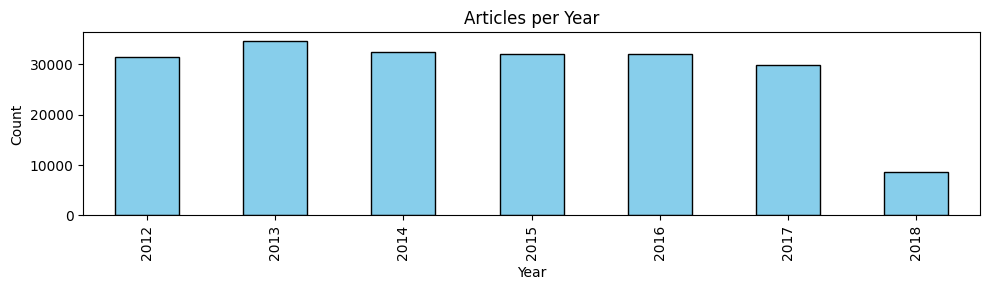

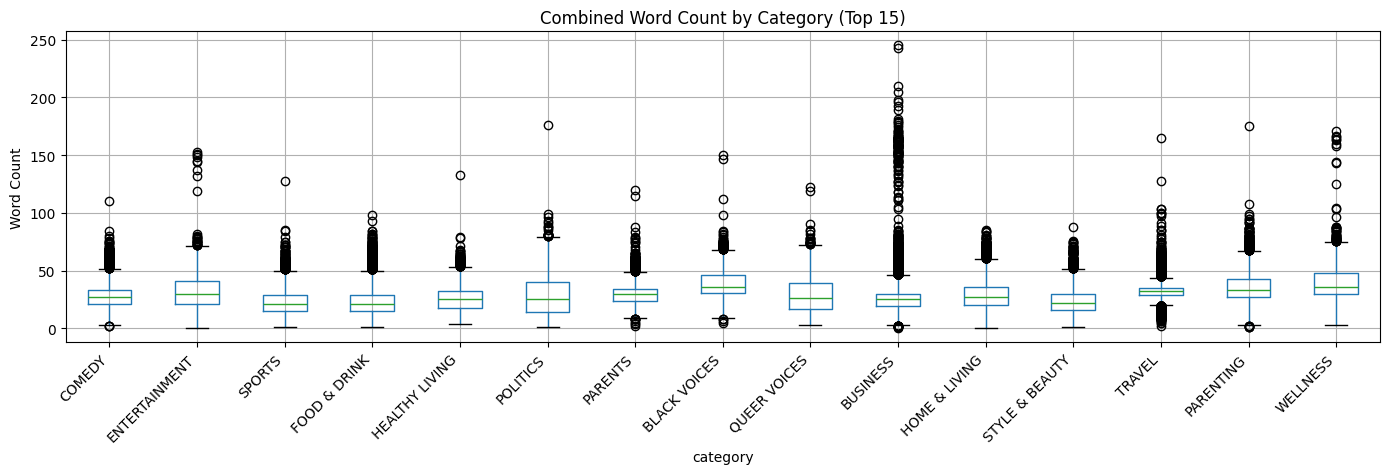

In [14]:
# ============================================================
# Section 7: Temporal Distribution & Per-Category Text Length
# ============================================================
# Show date range, articles per year, and word count variation by category.

# 7a: Date range and articles per year
dates_parsed = pd.to_datetime(huff_all['date'], errors='coerce')
print(f"Date range: {dates_parsed.min()} to {dates_parsed.max()}")

year_counts = dates_parsed.year.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 3))
year_counts.plot(kind='bar', ax=ax, color='skyblue', edgecolor='black')
ax.set_title('Articles per Year')
ax.set_ylabel('Count')
ax.set_xlabel('Year')
plt.tight_layout(); plt.show()

# 7b: Word count distribution by category (top 15 categories)
top15 = [c for c, _ in cat_counts.most_common(15)]
rows = []
for h, d, cat in zip(huff_all['headline'], huff_all['short_description'], huff_all['category']):
    if cat in top15:
        rows.append({'category': cat, 'wc': word_count(h) + word_count(d)})
wc_df = pd.DataFrame(rows)

# Order categories by median word count for readability
cat_order = wc_df.groupby('category')['wc'].median().sort_values().index
fig, ax = plt.subplots(figsize=(14, 5))
wc_df.boxplot(column='wc', by='category', ax=ax, rot=45, positions=range(len(cat_order)),
              return_type='dict')
ax.set_xticklabels(cat_order, rotation=45, ha='right')
ax.set_title('Combined Word Count by Category (Top 15)')
ax.set_ylabel('Word Count')
plt.suptitle('')  # remove auto-title from boxplot
plt.tight_layout(); plt.show()

### Graded Questions (2 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible.

1. **Dataset Summary:**  
   Describe your chosen dataset  (as if explaining to your *clueless boss* what you are working on).
   - State which dataset you are going to use.   
   - What kind of data does it contain (images or text)?  
   - How many samples and classes are there?  
   - What is the task you’ll perform (classification into what categories)?
   - What is the potential business use for this dataset?



1.1. **Dataset Summary:**

We chose the **HuffPost News Category Dataset**, a text-based collection of roughly **200,853 short news items** spanning **41 topical categories** (e.g., POLITICS, ENTERTAINMENT, PARENTING, TRAVEL, etc.). Each record contains a **headline** and a **short description**, which we concatenate with a `[SEP]` separator token to form the model input: `"headline [SEP] short_description"`. The task is **multi-class text classification**: given a news headline and its summary, predict which of the 41 editorial categories the article belongs to.

**Business use:** An automated topic-tagging system like this could power content recommendation engines, news aggregator feeds, or editorial dashboards. For example, a media company could use such a classifier to auto-route incoming articles to the correct editorial desk, populate topic-based RSS feeds, or surface trending topics by category in real time.

2. **Initial Observations:**  
   What stood out to you from your EDA?  
   - Did you notice any imbalanced or ambiguous classes?  
   - Any patterns, anomalies, or potential sources of bias?  
   - For images: note any variation in lighting, composition, or color.  
   - For text: mention redundancy, topic overlap, or very short examples.



1.2. **Initial Observations:**

Several findings stood out from our EDA:

- **Severe class imbalance:** The largest category (POLITICS, 32,739 samples) has 32.6x more samples than the smallest (EDUCATION, 1,004). The median class size (3,405) is well below the mean (~4,899), indicating a long tail of under-represented categories.
- **Near-synonym / overlapping categories:** Our confusable-group analysis identified 8 groups of categories that appear to be editorial renames or subsets of each other — e.g., PARENTS vs. PARENTING, ARTS vs. ARTS & CULTURE vs. CULTURE & ARTS, THE WORLDPOST vs. WORLDPOST vs. WORLD NEWS, STYLE vs. STYLE & BEAUTY, TASTE vs. FOOD & DRINK, GREEN vs. ENVIRONMENT, EDUCATION vs. COLLEGE, and HOME & LIVING vs. HEALTHY LIVING. These would likely confuse any classifier.
- **Missing data:** Our missing-data audit found 19,712 records (9.81%) with empty `short_description` fields and 36,620 (18.23%) with missing `authors`. Since the description contributes roughly two-thirds of the combined text (~19.7 of ~29.3 average words), these headline-only samples carry significantly less signal.
- **Duplicate headlines across categories:** 102 identical headlines appear under multiple categories (e.g., "Gingerbread Dessert Recipes…" in both TASTE and FOOD & DRINK), indicating genuine label ambiguity in the original editorial tagging. An additional 209 exact (headline + description) pairs exist as duplicates.
- **Short texts:** Combined word counts are low (mean 29.3, median 28, P95 = 56), making this a "short text" classification problem where every token carries outsized weight.
- **Non-discriminative vocabulary:** The top-10 most frequent words are all stop words (the, to, a, of, and, …), suggesting that simple bag-of-words approaches will need TF-IDF weighting or subword tokenization to surface meaningful signal.
- **Temporal skew:** The dataset spans 2012-01-28 to 2018-05-26 but article volume is concentrated in certain years, which could introduce temporal bias (e.g., political coverage spikes around elections).

3. **Challenges & Implications:**  
   Based on your inspection, what challenges might affect model performance or training (e.g., imbalance, ambiguous labels, variable quality)?  



1.3. **Challenges & Implications:**

- **Class imbalance** is the most pressing challenge. With a 32.6x ratio between the largest and smallest classes (POLITICS: 32,739 vs. EDUCATION: 1,004), a naive model could achieve reasonable overall accuracy by simply predicting the dominant categories while ignoring minority ones. This means accuracy alone is misleading, and we will need metrics like macro-F1 that give equal weight to all classes.
(We havent used f1 in our homeworks yet , but we hope to learn in the upcoming weeks)
- **Ambiguous / overlapping labels** create a hard ceiling on achievable accuracy. Our EDA found 102 headlines that appear under multiple categories (e.g., "How Successful People Stay Calm" filed under both HEALTHY LIVING and BUSINESS). This label noise will inflate error rates regardless of model quality.
- **Empty `short_description` fields** affect 19,712 records (9.81%). Since the description contributes roughly two-thirds of the combined text (~19.7 of ~29.3 average words), these samples lose a substantial portion of the available signal. If empty descriptions correlate with particular categories, the effect compounds with the imbalance issue.
- **Short text length** (median 28 words, P95 = 56 words combined) limits the capacity of bag-of-words models and makes every token count. Transformer models may also struggle since there is very little context to attend over.
- **Data leakage risk from duplicates:** Our audit found 209 exact (headline + description) duplicate pairs (697 rows) and 717 duplicate headlines (2,226 rows). If these end up in both train and test splits, the model will appear to generalize better than it actually does. Deduplication before splitting is essential.

4. **Preparation Ideas:**  
   What data-cleaning or preprocessing steps might help address these issues?  
   (You will not implement these yet—just describe what you might do later.)



1.4. **Preparation Ideas:**

- **Merge confusable categories** before any modeling. Our EDA identified 8 overlapping groups; the strongest merges would be: PARENTS + PARENTING, ARTS + ARTS & CULTURE + CULTURE & ARTS, THE WORLDPOST + WORLDPOST into WORLD NEWS, and STYLE + STYLE & BEAUTY. Additional candidates include TASTE + FOOD & DRINK, GREEN + ENVIRONMENT, EDUCATION + COLLEGE, and HOME & LIVING + HEALTHY LIVING. Merging all 8 groups would reduce 41 categories to roughly 31 cleaner labels.
- **Deduplicate** the 209 exact (headline + description) pairs before splitting to prevent data leakage. For the 717 headline-only duplicates that differ in description, keep both but verify they share the same category.
- **Drop or flag empty descriptions:** The 19,712 records (9.81%) with blank `short_description` should either be removed or retained with only headline text. At minimum, verify these don't disproportionately skew one category.
- **Stratified splitting** (80/10/10 train/val/test) with a fixed seed to preserve class proportions across splits.
- **Handle imbalance** via `class_weight='balanced'` in the loss function or via oversampling minority classes. We would try class weights first since it is simpler and doesn't increase dataset size.
- **Tokenization strategy:** For classical baselines, use TF-IDF on cleaned text (lowercased, stop-word-removed). For deep learning, use a subword tokenizer (e.g., DistilBERT's WordPiece) with `max_length` set near the 95th percentile (~56 words) to minimize truncation while keeping sequences manageable.

5. **Reflection:**  
   Why did you choose this dataset over the other one?  
   - What makes it more interesting, realistic, or relevant for you?  
   - What do you expect to learn from working with it?



1.5. **Reflection:**

All the team members were more inclined to do Huffpost for the following reasons :

- **Alignment with recent coursework:** Weeks 7-10 focused on NLP techniques (word embeddings, RNNs, BERT/DistilBERT fine-tuning). Choosing a text dataset lets us directly apply these state-of-the-art methods rather than revisiting CNN-based transfer learning we already completed in HW05.
- **Richer analytical challenges:** Our EDA revealed a 32.6x class imbalance, 8 groups of overlapping category labels, 9.81% missing descriptions, and 102 cross-category duplicate headlines, genuine data-science challenges that demand thoughtful preprocessing and metric selection. Food-101, by contrast, has balanced classes (1,000 images per class by design) with well-defined labels, offering fewer opportunities for meaningful EDA.
- **Faster iteration:** Text data is lightweight compared to 101k images. We can experiment with multiple model architectures (TF-IDF + Logistic Regression baseline, GloVe embeddings, LSTM, fine-tuned DistilBERT) without GPU bottlenecks, enabling a wider exploration of approaches.
- **Practical relevance:** Text classification is among the most common real-world ML applications (spam filtering, content moderation, customer support routing). Working through the full pipeline on messy, imbalanced text data mirrors real industry scenarios more closely than image classification on a curated benchmark.
- **Learning opportunity:** We expect to gain experience with macro-F1 as a primary metric, label merging as a preprocessing strategy, and the tradeoffs between classical NLP and transformer-based approaches at different data scales.


## Problem 2 – Frame the Problem (15 pts)

#### Objective

Identify the **key challenges** in your chosen dataset and outline **practical solutions** you would try, plus how you’ll **evaluate** them later.

#### Steps to follow

1. **Diagnose likely challenges (from your EDA):**

   Examples:
   * **Class imbalance:**
     Report label counts and an imbalance ratio (max / median). List any minority classes.
   * **Length/size variance:**
     For text, show length percentiles (50/75/90/95) and estimate truncation rate at candidate `max_text_length`s (e.g., 256/300/512). For images, summarize native resolutions.
   * **Noise/duplicates/leakage:**
     Note empty or malformed items, near-duplicates, and how you would prevent cross-split leakage.
   * **Ambiguous/overlapping labels:**
     Give 2–3 example pairs you expect to be confusable and why.
   * **Compute constraints:**
     Briefly state limits (RAM/GPU/CPU) that might affect batch size, sequence length, or image size.

2. **Map each challenge to a concrete solution plan:**

   Examples:
   * **Imbalance →** `class_weight` or oversampling; report which one you’d try first and why.
   * **Length/size →** pick a target `max_text_length` (e.g., 95th percentile) with masking; for images, standardize resize/crop and basic augmentation.
   * **Noise/duplicates →** dedupe (hash/near-dup), drop empty/very short items, document any relabeling.
   * **Ambiguity →** consider merging labels (if justified), or add features (bigrams/char-ngrams; simple image augmentations).
   * **Overfitting risk →** early stopping on your primary metric, dropout/weight decay, freeze-then-finetune plan (for pretrained features).

3. **Explore appropriate evaluation metrics:**

   Examples:
   * **Primary metric:** pick one aligned to your data (e.g., **macro-F1** if imbalanced; accuracy if balanced).
   * **Secondary metric(s):** per-class precision/recall, confusion matrix.
   * **Protocol:** stratified Train/Val/Test (e.g., 70/15/15), fixed seed, leakage checks.

4. **Answer the graded questions below.**



In [15]:
# Your code here, add as many cells as you like. Provide organization and structure by appropriate comments, labels, and variable names. Explain what
# you are doing in case you come back to this in a year.


# Identify and clean the Missing Data in the Header and Short Description

In [16]:

# 1. Identify the rows where headline is None, empty "", or just spaces "   "
blank_header_rows = [
    item for item in huff_all
    if not item.get("headline") or item.get("headline").strip() == ""
]

# 2. Print how many were found
print(f"Found {len(blank_header_rows)} rows with blank headlines.\n")

# 3. Inspect those 6 rows to check their short_description
for i, row in enumerate(blank_header_rows):
    print(f"--- Row Index {i+1} ---")
    print(f"Headline:          '{row.get('headline')}'")
    print(f"Short Description: '{row.get('short_description')}'")
    print(f"Category:          {row.get('category')}")
    print("-" * 30)

Found 6 rows with blank headlines.

--- Row Index 1 ---
Headline:          ''
Short Description: ''
Category:          POLITICS
------------------------------
--- Row Index 2 ---
Headline:          ''
Short Description: 'Let everyone not wrapped in tired and disproven doctrines about sex rid themselves of anti-scientific dogmas and be free. The law of grace, not of fear, can now blow freely.'
Category:          RELIGION
------------------------------
--- Row Index 3 ---
Headline:          ''
Short Description: ''
Category:          WORLDPOST
------------------------------
--- Row Index 4 ---
Headline:          ''
Short Description: ''
Category:          BUSINESS
------------------------------
--- Row Index 5 ---
Headline:          ''
Short Description: ''
Category:          MEDIA
------------------------------
--- Row Index 6 ---
Headline:          ''
Short Description: ''
Category:          QUEER VOICES
------------------------------


In [17]:
#Lets also check how the Missing Short Descriptions look and if they have empty headers
missing_desc_total = 0
both_missing = 0
desc_missing_but_has_header = 0

# Loop through the dataset
for item in huff_all:
    # Check if short_description is missing/empty
    desc = item.get("short_description") or ""
    if desc.strip() == "":
        missing_desc_total += 1

        # Now check the header for this specific record
        head = item.get("headline") or ""
        if head.strip() == "":
            both_missing += 1
        else:
            desc_missing_but_has_header += 1

print(f"Total records with missing Short Description: {missing_desc_total:,}")
print(f"  --> Of those, both Header AND Description are empty: {both_missing:,}")
print(f"  --> Of those, Short Description is empty BUT has a Header: {desc_missing_but_has_header:,}")

# Optional: Print the rows where both are empty to see if they are "trash" rows
if both_missing > 0:
    print("\n--- Examples of records where BOTH are missing ---")
    count = 0
    for item in huff_all:
        if (not item.get("short_description") or item.get("short_description").strip() == "") and \
           (not item.get("headline") or item.get("headline").strip() == ""):
            print(f"Category: {item.get('category')} | Date: {item.get('date')}")
            count += 1
            if count >= 5: break # Just show the first 5

Total records with missing Short Description: 19,712
  --> Of those, both Header AND Description are empty: 5
  --> Of those, Short Description is empty BUT has a Header: 19,707

--- Examples of records where BOTH are missing ---
Category: POLITICS | Date: 2015-08-22 00:00:00
Category: WORLDPOST | Date: 2015-03-29 00:00:00
Category: BUSINESS | Date: 2015-01-25 00:00:00
Category: MEDIA | Date: 2015-01-13 00:00:00
Category: QUEER VOICES | Date: 2014-08-28 00:00:00


# Based on this , we can safely remove those  6 news articles where the Header row is blank , since 5 of them also have their short description Blank.  For the rest of the articles where short description is blank , we will fill them with the header info .

In [18]:
# 1. Define a helper to check if a string is effectively empty
def is_blank(text):
    return not text or str(text).strip() == ""

# 2. Filter and Repair
cleaned_huff = []

for item in huff_all:
    head = item.get("headline") or ""
    desc = item.get("short_description") or ""

    # STEP A: Skip rows where BOTH are blank (The 6 rows you found)
    if is_blank(head) and is_blank(desc):
        continue  # This "drops" the row

    # STEP B: If description is missing but headline exists, copy headline over
    if is_blank(desc) and not is_blank(head):
        item["short_description"] = head

    # Add the valid/repaired item to our new list
    cleaned_huff.append(item)

# 3. Verify results
print(f"Original count: {len(huff_all):,}")
print(f"Cleaned count:  {len(cleaned_huff):,}")
print(f"Rows removed:   {len(huff_all) - len(cleaned_huff)}")

Original count: 200,853
Cleaned count:  200,848
Rows removed:   5


# Now Lets merge the confusable categories

In [19]:
# 1. Define the mapping dictionary
category_map = {
    'PARENTS': 'PARENTING',
    'ARTS & CULTURE': 'ARTS',
    'CULTURE & ARTS': 'ARTS',
    'WORLDPOST': 'THE WORLDPOST',
    'STYLE & BEAUTY': 'STYLE',
    'FOOD & DRINK': 'TASTE',
    'ENVIRONMENT': 'GREEN',
    'COLLEGE': 'EDUCATION',
    'HEALTHY LIVING': 'HOME & LIVING'
}

# 2. Update the categories in your cleaned list
for item in cleaned_huff:
    current_cat = item.get('category')
    # If current_cat is in map, use the map value; otherwise, keep current_cat
    item['category'] = category_map.get(current_cat, current_cat)

# 3. Verification: Check the new distribution
from collections import Counter
new_counts = Counter(item['category'] for item in cleaned_huff)

print("Updated category counts (Top 10):")
for cat, count in new_counts.most_common(10):
    print(f"{cat:20s}: {count:,}")


Updated category counts (Top 10):
POLITICS            : 32,738
WELLNESS            : 17,827
ENTERTAINMENT       : 16,058
PARENTING           : 12,632
STYLE               : 11,903
HOME & LIVING       : 10,889
TRAVEL              : 9,887
TASTE               : 8,322
QUEER VOICES        : 6,313
THE WORLDPOST       : 6,242


In [20]:
# 1. Get all categories from the cleaned list
all_cats = [item.get('category') for item in cleaned_huff]

# 2. Get unique categories and the total count
unique_categories = sorted(list(set(all_cats)))
num_unique = len(unique_categories)

# 3. Get the distribution (how many of each)
cat_counts = Counter(all_cats)

print(f"Total Unique Categories: {num_unique}")
print("-" * 30)
print("List of Unique Categories:")
print(unique_categories)

print("\nCounts per Category (Top 10):")
for cat, count in cat_counts.most_common(10):
    print(f"{cat:20s}: {count:,}")

Total Unique Categories: 32
------------------------------
List of Unique Categories:
['ARTS', 'BLACK VOICES', 'BUSINESS', 'COMEDY', 'CRIME', 'DIVORCE', 'EDUCATION', 'ENTERTAINMENT', 'FIFTY', 'GOOD NEWS', 'GREEN', 'HOME & LIVING', 'IMPACT', 'LATINO VOICES', 'MEDIA', 'MONEY', 'PARENTING', 'POLITICS', 'QUEER VOICES', 'RELIGION', 'SCIENCE', 'SPORTS', 'STYLE', 'TASTE', 'TECH', 'THE WORLDPOST', 'TRAVEL', 'WEDDINGS', 'WEIRD NEWS', 'WELLNESS', 'WOMEN', 'WORLD NEWS']

Counts per Category (Top 10):
POLITICS            : 32,738
WELLNESS            : 17,827
ENTERTAINMENT       : 16,058
PARENTING           : 12,632
STYLE               : 11,903
HOME & LIVING       : 10,889
TRAVEL              : 9,887
TASTE               : 8,322
QUEER VOICES        : 6,313
THE WORLDPOST       : 6,242


# Next we will Merge the Header and the short Description , Remove the duplicate rows so we can now use this clean dataset for our train and test split

In [21]:
# 1. Merge and De-duplicate
seen_texts = set()
final_huff = []

for item in cleaned_huff:
    # Create the combined text (Header + Space + Description)
    # We use .strip() to ensure no leading/trailing whitespace issues
    combined = f"{item.get('headline', '').strip()} {item.get('short_description', '').strip()}".strip()

    # 2. Check if we've seen this exact text before
    if combined not in seen_texts:
        # Add the new combined field to the dictionary
        item['combined_text'] = combined
        final_huff.append(item)

        # Add to our "seen" set so we don't pick it up again
        seen_texts.add(combined)

# 3. Report the results
original_count = len(cleaned_huff)
final_count = len(final_huff)
duplicates_removed = original_count - final_count

print(f"Original rows: {original_count:,}")
print(f"Final rows:    {final_count:,}")
print(f"Duplicates:    {duplicates_removed:,} ({(duplicates_removed/original_count)*100:.2f}%)")

# Show a quick preview of the new field
print("\nPreview of combined_text:")
print(final_huff[0]['combined_text'][:150] + "...")

Original rows: 200,848
Final rows:    200,364
Duplicates:    484 (0.24%)

Preview of combined_text:
There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV She left her husband. He killed their children. Just another day in America....


In [22]:
#Encode the category column
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Extract all categories
all_categories = [item['category'] for item in final_huff]

# Initialize and fit the encoder
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(all_categories)

# Add the 'label' key back into each dictionary in final_huff
for i, item in enumerate(final_huff):
    item['label'] = encoded_labels[i]

print(f"Encoded {len(label_encoder.classes_)} unique categories into labels.")

Encoded 32 unique categories into labels.


# Now we will handle the Imbalance issue. 2 Approaches
1. Oversampling - Oversampling works by identifying the "minority" classes (the ones with fewer rows) and duplicating those rows until they match the size of the "majority" class.  We do this only for the training set
2. Using Class weight -Class Weights tell the Loss Function to "pay more attention" to minority classes without duplicating any data.

We will try both. -  **bold text** **bold text**

In [23]:
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Create a simple list of indices [0, 1, 2, ..., N]
indices = np.arange(len(final_huff))
labels = [item['label'] for item in final_huff]

# 2. Split indices (not the actual dictionaries yet to save memory)
# stratify=labels ensures both sets have the same % of each category
idx_train, idx_test = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

# 3. Create the actual lists
train_data = [final_huff[i] for i in idx_train]
test_data  = [final_huff[i] for i in idx_test]

print(f"Initial Training rows: {len(train_data):,}")
print(f"Test rows (Keep these 'pure'): {len(test_data):,}")

Initial Training rows: 160,291
Test rows (Keep these 'pure'): 40,073


In [24]:
#OVERSAMPLING THE TRAINING SET
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

# 1. Prepare training inputs for the sampler
train_indices = np.arange(len(train_data)).reshape(-1, 1)
train_labels = [item['label'] for item in train_data]

# 2. Oversample
ros = RandomOverSampler(random_state=42)
idx_resampled, y_resampled = ros.fit_resample(train_indices, train_labels)

# 3. Create the final balanced training list
balanced_train_data = [train_data[i[0]] for i in idx_resampled]

print(f"Balanced Training rows: {len(balanced_train_data):,}")
print("\nFinal Verification:")
counts = Counter([item['category'] for item in balanced_train_data])
print(f"POLITICS count in Train:  {counts['POLITICS']:,}")
print(f"EDUCATION count in Train: {counts['EDUCATION']:,} (Now matches Politics!)")

Balanced Training rows: 837,664

Final Verification:
POLITICS count in Train:  26,177
EDUCATION count in Train: 26,177 (Now matches Politics!)


#Oversampling has increased the records of the Training set from 160K to 837K . oversampling can significantly slow down your training and, more importantly, it can lead to overfitting because the model sees the exact same "EDUCATION" or "ARTS" headlines thousands of times.  So lets go with the Class Weight Approach


In [25]:
from sklearn.utils import class_weight


# 1. Get the list of all labels in your ORIGINAL (unbalanced) training set
train_labels = [item['label'] for item in train_data]

# 2. Compute the weights
# 'balanced' mode uses the formula: n_samples / (n_classes * np.bincount(y))
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# 3. Convert to a dictionary (required by Keras)
# Format: {label_index: weight_value}
class_weight_dict = dict(enumerate(weights))

# 4. Quick Sanity Check
# Minority classes should have weights > 1, Majority should be < 1
for i, class_name in enumerate(label_encoder.classes_):
  print(f"Category: {class_name:20s} | Weight: {class_weight_dict[i]:.2f}")


Category: ARTS                 | Weight: 1.62
Category: BLACK VOICES         | Weight: 1.38
Category: BUSINESS             | Weight: 1.06
Category: COMEDY               | Weight: 1.21
Category: CRIME                | Weight: 1.84
Category: DIVORCE              | Weight: 1.83
Category: EDUCATION            | Weight: 2.92
Category: ENTERTAINMENT        | Weight: 0.39
Category: FIFTY                | Weight: 4.47
Category: GOOD NEWS            | Weight: 4.48
Category: GREEN                | Weight: 1.59
Category: HOME & LIVING        | Weight: 0.58
Category: IMPACT               | Weight: 1.81
Category: LATINO VOICES        | Weight: 5.55
Category: MEDIA                | Weight: 2.23
Category: MONEY                | Weight: 3.67
Category: PARENTING            | Weight: 0.50
Category: POLITICS             | Weight: 0.19
Category: QUEER VOICES         | Weight: 0.99
Category: RELIGION             | Weight: 2.46
Category: SCIENCE              | Weight: 2.88
Category: SPORTS               | W

# We need to remember to pass this class weight when we are training the model

## **Next we will tokenize merged (header and short Description) , check the stats to identify the max length and the training vocabulary size as done in homework 7 **

In [26]:
from tensorflow.keras.preprocessing.text import Tokenizer
# 1. Extract combined text from the training data only
train_texts = [item['combined_text'] for item in train_data]

# 2. Initialize Tokenizer (no cap yet so we can measure full coverage)
tokenizer = Tokenizer(lower=True, filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n')
tokenizer.fit_on_texts(train_texts)

# 3. Convert texts to sequences of integers
train_sequences = tokenizer.texts_to_sequences(train_texts)

print(f"Total training articles processed: {len(train_sequences):,}")

Total training articles processed: 160,291


--- Training Sequence Length Stats ---
Max length:    228 tokens
Mean length:   30.5 tokens
Median length: 29 tokens
90th percentile: 49 tokens
95th percentile: 56 tokens
99th percentile: 67 tokens


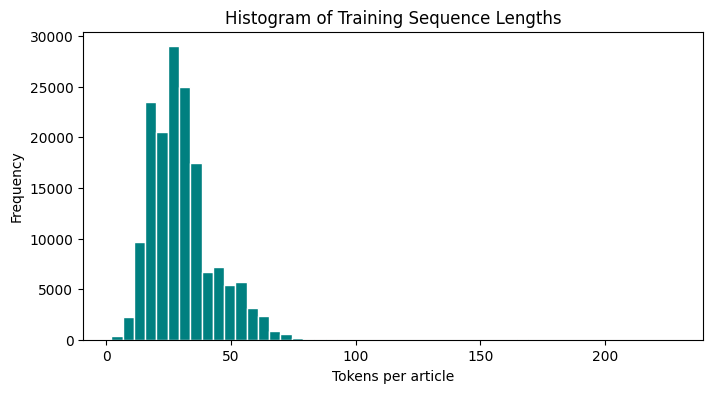

In [27]:
# Calculate lengths of each sequence
lengths = np.array([len(s) for s in train_sequences])

print("--- Training Sequence Length Stats ---")
print(f"Max length:    {lengths.max()} tokens")
print(f"Mean length:   {lengths.mean():.1f} tokens")
print(f"Median length: {np.median(lengths):.0f} tokens")

# Identify the percentiles for maxlen decision
for q in (90, 95, 99):
    print(f"{q}th percentile: {int(np.percentile(lengths, q))} tokens")

plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=50, color='teal', edgecolor='white')
plt.title("Histogram of Training Sequence Lengths")
plt.xlabel("Tokens per article")
plt.ylabel("Frequency")
plt.show()


--- Training Vocabulary Stats ---
Total Unique Words in Train: 104,840
Total Word Tokens in Train: 4,894,782

Coverage Metrics:
num_words= 5,000 | Coverage:  85.51%
num_words=10,000 | Coverage:  91.54%
num_words=20,000 | Coverage:  95.72%
num_words=30,000 | Coverage:  97.34%
num_words=40,000 | Coverage:  98.17%
num_words=50,000 | Coverage:  98.68%


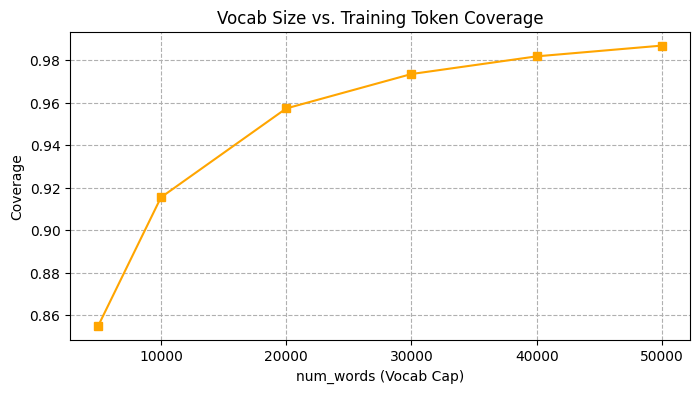

In [28]:
# 1. Get word counts and sort them by frequency (descending)
# Note: Keras word_index is already sorted by frequency rank
word_freqs = sorted(tokenizer.word_counts.values(), reverse=True)
cum_tokens = np.cumsum(word_freqs)
total_tokens_in_train = cum_tokens[-1]
total_unique_words = len(word_freqs)

print(f"\n--- Training Vocabulary Stats ---")
print(f"Total Unique Words in Train: {total_unique_words:,}")
print(f"Total Word Tokens in Train: {total_tokens_in_train:,}")

def calculate_coverage(vocab_cap):
    # Keras reserves Index 0 for Padding, so 'vocab_cap' includes that.
    # We look at the top (vocab_cap - 1) words.
    actual_cap = min(vocab_cap - 1, total_unique_words)
    if actual_cap <= 0: return 0.0
    return cum_tokens[actual_cap - 1] / total_tokens_in_train

# 2. Check Candidate Caps
candidate_caps = [5_000, 10_000, 20_000, 30_000, 40_000, 50_000]
print("\nCoverage Metrics:")
for cap in candidate_caps:
    coverage = calculate_coverage(cap)
    print(f"num_words={cap:>6,} | Coverage: {coverage*100:6.2f}%")

# Plot Coverage
plt.figure(figsize=(8, 4))
plt.plot(candidate_caps, [calculate_coverage(c) for c in candidate_caps], marker='s', color='orange')
plt.title("Vocab Size vs. Training Token Coverage")
plt.xlabel("num_words (Vocab Cap)")
plt.ylabel("Coverage")
plt.grid(True, linestyle="--")
plt.show()

### Graded Questions (3 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible.

1. **State the prediction task**  
   - Describe what your model will predict (the *label*).  
   - *Examples:*  
     - “Given a photo of food, predict which of 101 categories it belongs to.”  
     - “Given a news headline + summary, predict its topical category.”  

2.1. **Your answer here:**

There a multiple options for what the model can predict:


1.   When provided a headline and short description, predict the category the article belongs in
2.   When provided a headline or short description, predict if the article can be classified as hard vs. soft news (ChatGPT provided this as a classification option)
3. When provided a headline and short description, predict if the article could belong multiple categories
4. When provided the number of words in the headline and short description, predict the length of the article






2. **Define inputs and outputs**  
   - *Inputs:* what information the model receives (e.g., pixel data, tokenized text).  
   - *Outputs:* the categorical label the model will predict.  

2.2. **Your answer here:**


1.   Input = headline + short description | Output: category label   
2.   Input = headline or short description | Output: hard (politics, business, etc) vs. soft (entertainment, style, etc)
3. Input = headline + short description | Output: all possible category labels
4. Input = word count in headline + short description | Output: length of the article

In each of the scenarios , Tokenized text will be sent to the Model
The max length for the tokens would be set to 64 based on the pre-processing analysis explained below





3. **Identify possible challenges**  
   - Imbalanced classes, noisy data, ambiguous labels, overlapping features, or missing data  
   - *Images:* variation in lighting, color, composition, or size.  
   - *Text:* class imbalance, duplicate stories, short or ambiguous headlines.  

2.3. **Your answer here:**
Some possible challeneges that were identified from the EDA above was severe class imbalance, overlapping categories, missing data from the short_description field and author field, duplicate headlines across multiple categories that belong to different articles.
Explanation provided below to question 4 on the pre-processing steps implemented to overcome the challenges




4. **Propose how you will prepare or improve the data to address the challenges**  
   - *Images:* resizing, normalization, data augmentation (flips, rotations, brightness, color jitter).  
   - *Text:* tokenization, stop-word removal, TF-IDF, class balancing, embeddings (choose an embedding approach and specify its vector size).

2.4. **Your answer here:**
The following preprocessing steps were implemented to address these issues.

**1. Handling Missing Data**

The dataset contained missing values in both the headline and short description fields.
5 records were found with missing headlines
19,712 records had missing short descriptions

Of these, all 5 records with missing headlines also had missing descriptions.

**Approach:**
Removed the 5 records with missing headlines, as they provide no usable textual information.
For the remaining records with missing short descriptions: The headline was used as a substitute for the missing description.
**Justification:**
Since the headline carries meaningful information, this approach preserves data while avoiding unnecessary data loss.

**2. Merging Confusable Categories**

EDA revealed multiple overlapping or near-synonymous categories (e.g., ARTS vs ARTS & CULTURE, PARENTS vs PARENTING).

**Approach:**
Merged similar categories to reduce ambiguity.
Reduced total categories from 41 to 32.
**Justification:** This improves model performance by:
Reducing label noise
Minimizing confusion between semantically similar classes

**3. Text Consolidation and Deduplication**
**Approach:**
Combined: Headline + Short Description → single text field
Removed duplicate records: Original dataset: 200,848 rows
Final dataset: 200,364 rows
Duplicates removed: 484 (0.24%)

**Justification:**
Combining fields increases contextual information (important for short-text classification)
Removing duplicates prevents the model from learning redundant patterns

**4. Handling Class Imbalance**

The dataset exhibited severe class imbalance, with some categories significantly underrepresented.

**Approach 1: Oversampling**
Minority classes were duplicated to match the majority class size
Result:
Training data increased from ~160K to 837,664 rows
**Limitation:**
Increased computational cost
Risk of overfitting due to repeated samples

**Approach 2: Class Weights (Selected Approach)**

Instead of duplicating data, class weights were applied during training:

Example:

EDUCATION → weight 2.92 (rare class)
ENTERTAINMENT → weight 0.39 (frequent class)
**Justification:**
Penalizes misclassification of minority classes more heavily
Avoids dataset inflation
Reduces risk of overfitting

Final choice: Class weight approach will be used when we start the modelling exercise

**5. Tokenization and Sequence Length Analysis**

Tokenization was applied to the combined text to understand sequence characteristics.

Sequence Length Statistics:
Mean: 30.5 tokens
Median: 29 tokens
90th percentile: 49 tokens
95th percentile: 56 tokens
99th percentile: 67 tokens
Max: 228 tokens

**Approach:**
Selected MAX_LEN ≈ 64 tokens

**Justification:**
Covers ~95% of the data without truncation
Balances performance and computational efficiency

**6. Vocabulary Analysis**
Statistics:
Unique words: 104,840
Total tokens: ~4.9 million
Coverage Analysis:
Vocabulary Size	Coverage
5,000	85.51%
10,000	91.54%
20,000	95.72%
30,000	97.34%
50,000	98.68%
**Justification:**
A vocabulary size of 20K–30K provides strong coverage while controlling dimensionality
Supports both TF-IDF and embedding-based approaches


5. **Specify success metrics**  
   - Identify the metrics you plan to use to evaluate model performance—typically **accuracy** and/or **F1-score**, which are standard for classification tasks.  
   - Briefly explain **why** these metrics are appropriate for your dataset and goal. For instance, accuracy may suffice for well-balanced datasets, while F1-score better reflects performance when some classes are under-represented.
   - If your dataset is **imbalanced**, consider computing **per-class metrics** (e.g., precision, recall, or F1 for each label) or **macro-averaged** scores, which give equal weight to each class regardless of its size—ensuring that minority classes are evaluated fairly.
In some cases, weighted averages (which weight classes by their frequency) or **confusion matrices** can also provide useful insight.
> You haven't run any models yet, and we haven’t studied every possible metric, but you’re encouraged to ask your favorite generative AI tool which evaluation metrics might best fit your dataset!
   - Clearly state how you will interpret success—for example, “Our goal is to achieve at least 80% overall accuracy without large per-class disparities.”

2.5. **Success Metrics:**

To evaluate model performance, we will use:

- **Primary metric: Macro F1-score** — averages F1 across all classes equally, ensuring minority classes are not ignored despite the severe class imbalance.
- **Secondary metric: Weighted F1-score** — weights each class by its frequency, providing a view of real-world performance. This is less strict than macro F1 since frequent classes dominate the average.
- **Training monitors:** Cross-entropy loss (to guide optimization and assess convergence) and validation accuracy (tracked at each epoch). The best-performing model will be selected based on validation performance to avoid overfitting.

**Success criteria:**
- Macro F1-score ≥ 0.70, ensuring balanced performance across all classes
- Weighted F1-score ≥ 0.75, indicating strong overall predictive performance
- No individual class with F1-score below 0.50, ensuring minority classes are not neglected

Note: We have limited prior experience with F1-score (it was briefly used in HW09), so we expect to deepen our understanding of these metrics as the project progresses.

### Final Question: Describe what use you made of generative AI tools in preparing this Milestone.

**AI Usage:**

We used generative AI tools (ChatGPT and Claude Code) in the following ways:

- **Metric selection (Q2.5):** As encouraged in the assignment, we asked ChatGPT which evaluation metrics best fit an imbalanced multi-class text classification task. It recommended macro F1-score as the primary metric and weighted F1 as a secondary metric.
- **Response framing:** Used ChatGPT to help structure and clarify our written answers based on the EDA results we produced.
- **Answer verification:** Used Claude Code to cross-check that our written answers accurately cited the quantitative EDA outputs (e.g., verifying exact imbalance ratios, missing data percentages, and duplicate counts matched the code output).

---

## Appendix: A quick guide to Hugging Face Datasets

#### 1) What are they?

* A **table-like** dataset: rows = examples, columns = named fields (e.g., `"image"`, `"label"`, `"headline"`).
* Backed by **Apache Arrow** → fast, memory-efficient, lazy transforms.
* Two core objects:

  * `Dataset` — one table of rows/columns.
  * `DatasetDict` — a dict of splits, e.g. `{"train": Dataset, "val": Dataset, "test": Dataset}`.


#### 2) Load and inspect

```python
from datasets import load_dataset

# Food-101 (images)
food = load_dataset("food101", split="train+validation")  # both splits at once
len(food), food.column_names, food.features
# -> (≈101000, ['image','label'], {'label': ClassLabel(num_classes=101, names=[...])})

# Access by name (not by numeric column index!)
row0 = food[0]
img0, y0 = row0["image"], row0["label"]     # PIL image, int id
label_names = food.features["label"].names
label_names[y0]
```

For text (HuffPost JSON mirror):

```python
url = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff = load_dataset("json", data_files=url, split="train")
huff.column_names  # e.g. ['headline','short_description','category','authors','link','date']
```


#### 3) Common transforms

`Dataset`s are **immutable**: ops return a new dataset.

* **Map** (add/modify columns):

```python
def mk_text(ex):
    h = (ex.get("headline") or "").strip()
    s = (ex.get("short_description") or "").strip()
    return {"text": (h + " [SEP] " + s).strip()}

huff = huff.map(mk_text)  # adds 'text' column
```

* **Class-encode** labels (strings → integers with a vocabulary):

```python
from datasets.features import ClassLabel
if not isinstance(huff.features["category"], ClassLabel):
    huff = huff.class_encode_column("category")  # now ints with .names
```

* **Filter / select / rename / drop**:

```python
small = huff.select(range(5000))  # first 5k rows
huff = huff.remove_columns(["authors","link","date"])
huff = huff.rename_column("category", "label")
```


#### 4) Splitting & shuffling

```python
# Stratified 80/10/10 on Food-101 by 'label'
from datasets import DatasetDict
label_col = "label"

tmp = food.train_test_split(test_size=0.10, seed=42, stratify_by_column=label_col)
train_val = tmp["train"].train_test_split(test_size=1/9, seed=42, stratify_by_column=label_col)
ds = DatasetDict(train=train_val["train"], val=train_val["test"], test=tmp["test"])

len(ds["train"]), len(ds["val"]), len(ds["test"])
```

* `train_test_split` is **random by default** (reproducible with `seed=`).
* You typically **don’t need to pre-shuffle** datasets if your training dataloader already shuffles each epoch.


#### 5) Working with images

Use `with_transform` to apply on-the-fly resizing/augmentation and return tensors:

```python
import torchvision.transforms as T
from torch.utils.data import DataLoader
import torch, math, random

IM_SIZE = 224
train_tfms = T.Compose([T.RandomResizedCrop(IM_SIZE), T.RandomHorizontalFlip(), T.ToTensor()])
eval_tfms  = T.Compose([T.Resize(256), T.CenterCrop(IM_SIZE), T.ToTensor()])

def add_pixel_values(ex, tfms):  # ex['image'] -> ex['pixel_values']
    ex = dict(ex); ex["pixel_values"] = tfms(ex["image"]); return ex

train_t = ds["train"].with_transform(lambda ex: add_pixel_values(ex, train_tfms))
val_t   = ds["val"].with_transform(lambda ex: add_pixel_values(ex, eval_tfms))

def collate(batch):
    return {"pixel_values": torch.stack([b["pixel_values"] for b in batch]),
            "labels": torch.tensor([b["label"] for b in batch])}

train_loader = DataLoader(train_t, batch_size=64, shuffle=True,  collate_fn=collate)
val_loader   = DataLoader(val_t,   batch_size=64, shuffle=False, collate_fn=collate)
```

### 6) Working with Text

You can preprocess and tokenize text datasets using either a **transformer tokenizer** or a **linguistic pipeline like spaCy**, depending on your model type and goals.


#### Option A: Transformer Tokenizer (for fine-tuning models like BERT or DistilBERT)

Use a pretrained tokenizer with the Hugging Face `map` method to efficiently process your dataset in batches:

```python
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tok(batch["text"], truncation=True, padding="max_length", max_length=128)

tokenized = huff.map(
    tokenize,
    batched=True,
    remove_columns=[c for c in huff.column_names if c not in ("category", "label")]
)
```

This produces token IDs, attention masks, and other fields expected by transformer models.
Use this approach if your project involves fine-tuning pretrained language models.


#### Option B: spaCy Tokenization and Cleaning (for classical ML or custom preprocessing)

If you are **not using transformers**, or if you want to explore feature engineering (e.g., TF-IDF, word frequency, or embedding averages), you can preprocess text with **spaCy** instead.

```python
# !pip install spacy
# !python -m spacy download en_core_web_sm

import spacy
from datasets import load_dataset

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser", "textcat"])
STOP = spacy.lang.en.stop_words.STOP_WORDS

def spacy_clean(batch):
    docs = list(nlp.pipe(batch["text"], batch_size=1000))
    cleaned = []
    for doc in docs:
        tokens = [t.lemma_.lower() for t in doc if t.is_alpha and not t.is_stop]
        cleaned.append(" ".join(tokens))
    return {"text_clean": cleaned, "len_tokens": [len(c.split()) for c in cleaned]}

huff = huff.map(
    spacy_clean,
    batched=True,
    batch_size=1000,
    remove_columns=[c for c in huff.column_names if c not in ("category", "label")]
)
```

The resulting column `text_clean` can be used with:

* `TfidfVectorizer` (Scikit-learn)
* `TextVectorization` (Keras)
* or any other custom embedding method.

> 💡 **Tip:** spaCy is ideal for lightweight NLP pipelines or for models that rely on explicit preprocessing (lemmatization, stopword removal). Transformer tokenizers, by contrast, expect *raw text* and handle subword tokenization internally.



#### 7) Slicing, concatenating, saving

```python
# Slicing
head_1000 = food.select(range(1000))
tail_10pct = food.select(range(int(0.9*len(food)), len(food)))

# Concatenate splits/datasets
from datasets import concatenate_datasets
all_train = concatenate_datasets([ds["train"], ds["val"]])

# Save / reload
ds.save_to_disk("food101_splits")
from datasets import load_from_disk
ds2 = load_from_disk("food101_splits")
```


#### 8) Quick “gotchas”

* **Columns by name** (strings), not numeric indices.
* Avoid converting huge columns to `list(...)` unless necessary; prefer vectorized ops with `map`, `filter`, `select`.
* `PYTHONHASHSEED` must be set **before** the Python process starts to matter; use explicit `seed=` arguments for reproducibility.
* Datasets print **previews** (e.g., `Column([6, 6, 6, ...])` is just the first few values).


#### 9) A minimal checklist to follow

1. `load_dataset(...)` → confirm `column_names`, `features`.
2. Build any needed columns (`"text"`), and **class-encode** labels if strings.
3. Make a **stratified 80/10/10** split (`train_test_split` ×2).
4. Do **EDA**: class counts, sample printouts or image grids.
5. For training:

   * **images** → `with_transform` + DataLoader
   * **text** → tokenizer via `.map(...)` + trainer/model pipeline
6. Save your `DatasetDict` with `save_to_disk(...)` (optional for text but handy, **don't** use it for big image datasets).

